# 01 - Telemetry Data Analysis

## Objective

This notebook performs an exploratory analysis of the quadcopter telemetry.

The goals are:

- Load raw telemetry
- Validate the dataset
- Inspect sensor quality
- Estimate sampling frequency
- Visualize IMU signals
- Apply preprocessing
- Compare raw and filtered measurements

This notebook does not perform optimization.

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

In [11]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from src.telemetry import TelemetryLoader
from src.processing import SignalProcessor

plt.style.use("seaborn-v0_8-darkgrid")

## Load Telemetry

Load the raw telemetry file from the data directory.

In [12]:
loader = TelemetryLoader()

df = loader.load("test_run_01.csv")

df.head()

Loaded test_run_01.csv: 500 rows @ ~100.0Hz


,dt,ax_raw,ay_raw,az_raw,gx_raw,gy_raw,gz_raw,ax_g,ay_g,az_g,gyroX_dps,gyroY_dps,gyroZ_dps,roll_deg,pitch_deg,yaw_deg
0,0.01,461,744,16113,2181,-3524,626,-0.016747,0.024704,0.952165,16.653726,-26.903300,4.785106,3.185236,7.149014,0.069968
1,0.01,-269,248,16772,-3561,-954,359,-0.028686,-0.087379,0.959178,-27.190495,-7.284045,2.746194,3.348207,6.882825,0.116199
2,0.01,913,994,15389,-2391,1471,-204,0.082345,-0.035078,1.018095,-18.254356,11.229747,-1.564722,2.645859,7.004489,0.119181
3,0.01,-395,371,15581,312,-3960,-7,-0.091942,0.034551,1.037932,2.386397,-30.234733,-0.055711,2.990587,7.115810,0.086834
4,0.01,-544,-9,16067,-2133,-6237,314,0.002443,-0.032547,1.001423,-16.283226,-47.612704,2.398268,2.693716,6.401669,0.121745


## Dataset Information

Inspect the structure and data types.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   dt         500 non-null    float64
 1   ax_raw     500 non-null    int64  
 2   ay_raw     500 non-null    int64  
 3   az_raw     500 non-null    int64  
 4   gx_raw     500 non-null    int64  
 5   gy_raw     500 non-null    int64  
 6   gz_raw     500 non-null    int64  
 7   ax_g       500 non-null    float64
 8   ay_g       500 non-null    float64
 9   az_g       500 non-null    float64
 10  gyroX_dps  500 non-null    float64
 11  gyroY_dps  500 non-null    float64
 12  gyroZ_dps  500 non-null    float64
 13  roll_deg   500 non-null    float64
 14  pitch_deg  500 non-null    float64
 15  yaw_deg    500 non-null    float64
dtypes: float64(10), int64(6)
memory usage: 62.6 KB


In [14]:
df.describe()

,dt,ax_raw,ay_raw,az_raw,gx_raw,gy_raw,gz_raw,ax_g,ay_g,az_g,gyroX_dps,gyroY_dps,gyroZ_dps,roll_deg,pitch_deg,yaw_deg
count,500.00,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.01,-19.36600,34.300000,16039.352000,-72.476000,-200.640000,70.922000,0.001172,-0.003399,0.999444,-0.553211,-1.531730,0.541898,0.032034,0.028276,1.346637
std,0.00,584.02005,590.910823,590.093862,1854.676088,3244.206182,463.439117,0.056996,0.057481,0.030004,14.160875,24.767909,3.540671,0.714861,1.808284,0.501983
min,0.01,-997.00000,-994.000000,15000.000000,-5365.000000,-9461.000000,-1363.000000,-0.099671,-0.099585,0.950063,-40.958128,-72.222952,-10.406044,-1.930392,-5.482481,0.069968
25%,0.01,-531.50000,-493.000000,15519.750000,-1264.250000,-2403.500000,-239.250000,-0.047882,-0.051506,0.972189,-9.655104,-18.353827,-1.830455,-0.228958,-0.533214,1.075616
50%,0.01,-40.50000,63.500000,16091.500000,-28.500000,-98.500000,84.000000,0.002866,-0.008446,1.000054,-0.222640,-0.754987,0.643521,0.010233,-0.031595,1.400909
75%,0.01,471.00000,553.500000,16541.750000,1168.000000,1999.250000,392.000000,0.050006,0.045532,1.025206,8.919750,15.262383,2.994155,0.260776,0.564357,1.586077
max,0.01,989.00000,997.000000,16999.000000,4887.000000,9073.000000,1332.000000,0.099095,0.099810,1.049832,37.309444,69.264428,10.171897,3.348207,7.149014,2.712113


## Dataset Summary

Obtain a quick overview of the telemetry.

In [15]:
summary = {
    "rows"      : len(df),
    "columns"   : list(df.columns),
    "duration_s": df["dt"].sum(),
    "avg_dt"    : df["dt"].mean(),
    "missing"   : df.isnull().sum().to_dict()
}

summary

{'rows': 500,
 'columns': ['dt',
  'ax_raw',
  'ay_raw',
  'az_raw',
  'gx_raw',
  'gy_raw',
  'gz_raw',
  'ax_g',
  'ay_g',
  'az_g',
  'gyroX_dps',
  'gyroY_dps',
  'gyroZ_dps',
  'roll_deg',
  'pitch_deg',
  'yaw_deg'],
 'duration_s': np.float64(5.0),
 'avg_dt': np.float64(0.01),
 'missing': {'dt': 0,
  'ax_raw': 0,
  'ay_raw': 0,
  'az_raw': 0,
  'gx_raw': 0,
  'gy_raw': 0,
  'gz_raw': 0,
  'ax_g': 0,
  'ay_g': 0,
  'az_g': 0,
  'gyroX_dps': 0,
  'gyroY_dps': 0,
  'gyroZ_dps': 0,
  'roll_deg': 0,
  'pitch_deg': 0,
  'yaw_deg': 0}}

## Raw Sensor Signals

Visualize the recorded pitch, roll and yaw angles.

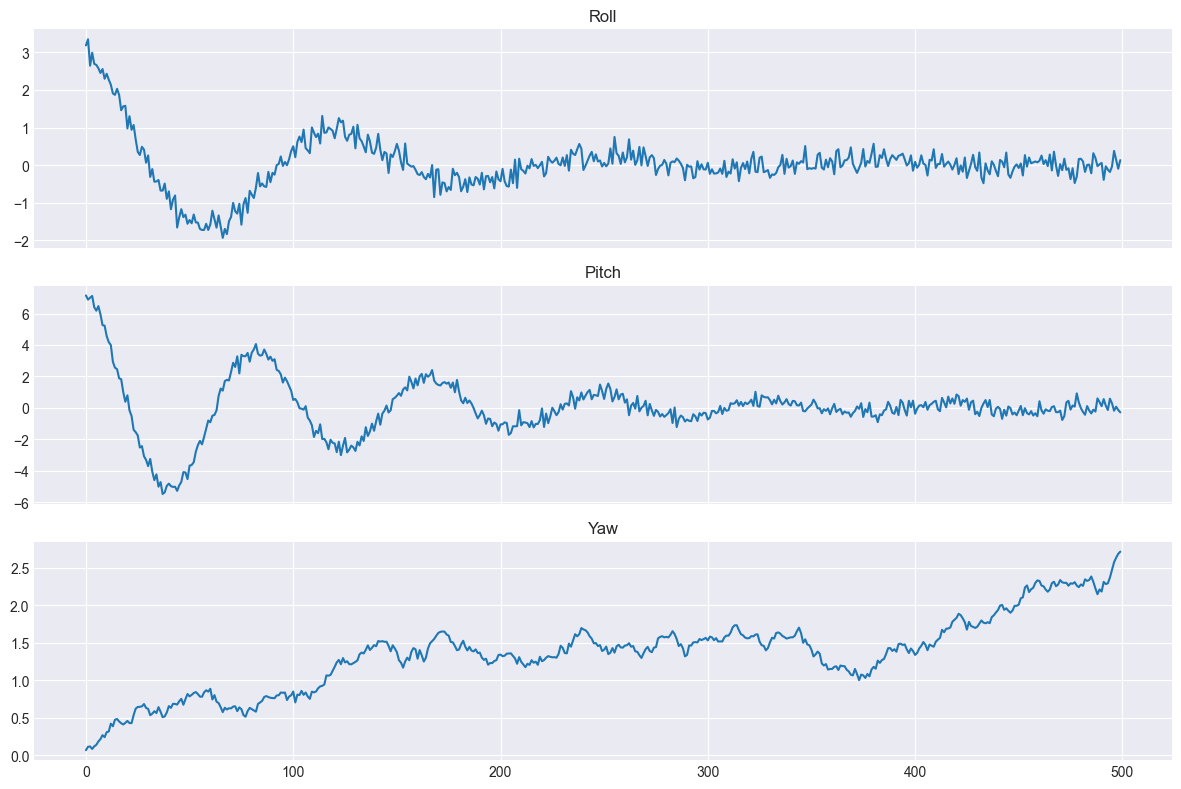

In [16]:
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

ax[0].plot(df["roll_deg"])
ax[0].set_title("Roll")

ax[1].plot(df["pitch_deg"])
ax[1].set_title("Pitch")

ax[2].plot(df["yaw_deg"])
ax[2].set_title("Yaw")

plt.tight_layout()

plt.show()

## Gyroscope Signals

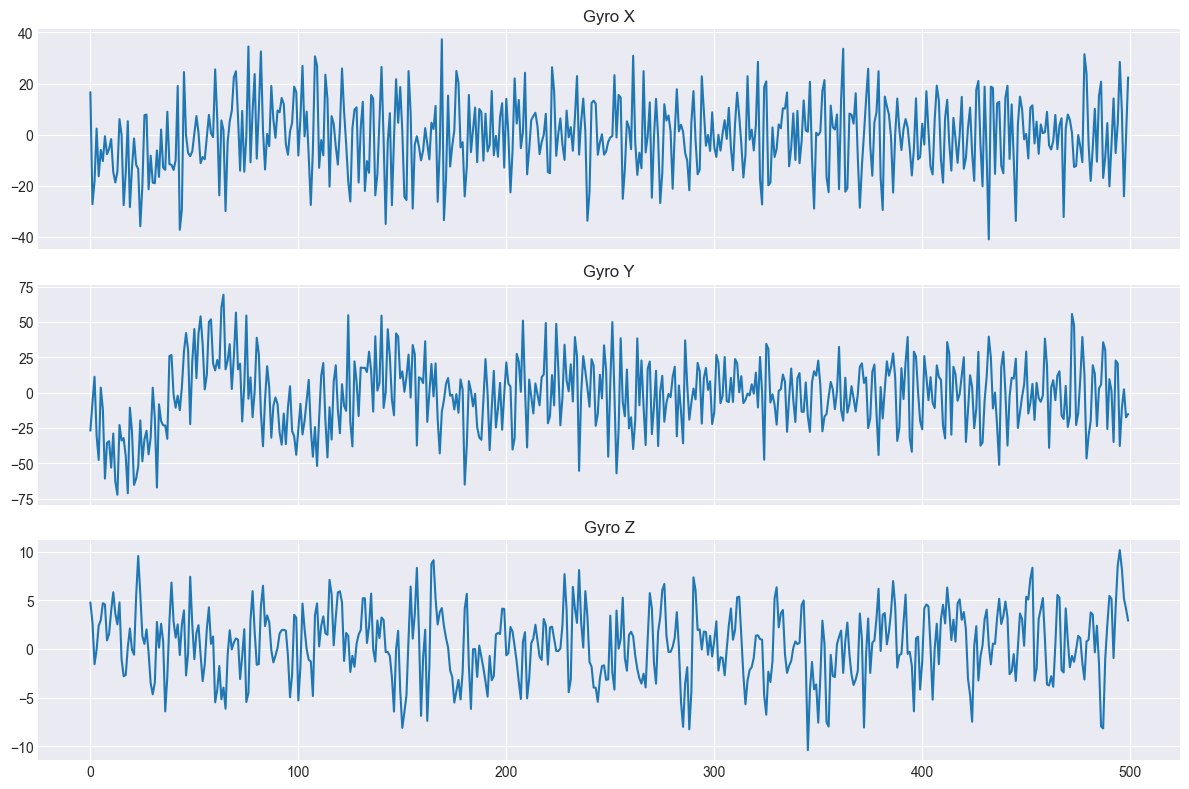

In [17]:
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

ax[0].plot(df["gyroX_dps"])
ax[0].set_title("Gyro X")

ax[1].plot(df["gyroY_dps"])
ax[1].set_title("Gyro Y")

ax[2].plot(df["gyroZ_dps"])
ax[2].set_title("Gyro Z")

plt.tight_layout()

plt.show()

## Signal Processing

Apply preprocessing to reduce sensor noise.

In [18]:
processor = SignalProcessor()

processed = processor.process_dataframe(df)

## Raw vs Filtered Pitch Signal

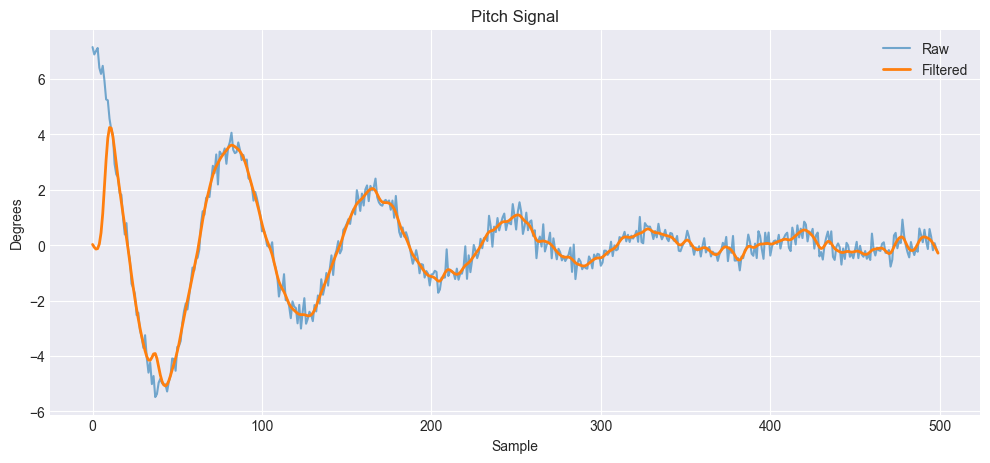

In [19]:
plt.figure(figsize=(12,5))

plt.plot(
    df["pitch_deg"],
    label="Raw",
    alpha=0.6
)

plt.plot(
    processed["pitch_deg"],
    label="Filtered",
    linewidth=2
)

plt.legend()

plt.title("Pitch Signal")

plt.xlabel("Sample")

plt.ylabel("Degrees")

plt.show()

## Sensor Noise Estimation

In [20]:
noise = processor.estimate_noise(df["gyroY_dps"])

noise

{'mean': -1.5317297734062711,
 'std': 24.74312840804794,
 'variance': 612.2224034171489}

## Conclusion

This notebook verified the integrity of the telemetry dataset and demonstrated the preprocessing pipeline used before system identification and optimization.

The processed signals produced here are used throughout the remaining notebooks.